In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from matplotlib.animation import FuncAnimation
from matplotlib.transforms import blended_transform_factory
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

# Homework 1

In [2]:
df = pd.read_csv (r'fertility-vs-child-mortality.csv') 

## Extracting DataFrames for 2015, 2020, and 2021

In [3]:
# Select the data where **Pop, Fer\_rate, and Child\_mort are not NaN**.
mask_Nan = df[[
    "Population (historical estimates)",
    "Fertility rate - Sex: all - Age: all - Variant: estimates",
    "Child mortality rate - Sex: all - Age: 0-4 - Variant: estimates"
]].notnull().all(axis=1)

df_ = df[mask_Nan].copy()

# 2015 continent mapping
df_2015 = df_[df_["Year"] == 2015].copy()

map_main = (df_2015
            .dropna(subset=["Code", "Continent"])
            .drop_duplicates(subset=["Code"], keep="last")
            .set_index("Code")["Continent"])

map_fallback = (df_2015
                .dropna(subset=["Entity", "Continent"])
                .drop_duplicates(subset=["Entity"], keep="last")
                .set_index("Entity")["Continent"])

def fill_continent(df_year):
    out = df_year.copy()
    out["Continent_filled"] = out["Code"].map(map_main)
    mask = out["Continent_filled"].isna()
    out.loc[mask, "Continent_filled"] = out.loc[mask, "Entity"].map(map_fallback)
    out["Continent"] = out["Continent"].fillna(out["Continent_filled"])
    return out.drop(columns=["Continent_filled"])

# generate 2020 / 2021
df_2020 = fill_continent(df_[df_["Year"] == 2020])
df_2021 = fill_continent(df_[df_["Year"] == 2021])


# For 2015

### Data Processing

In [4]:
# Simplify column names
fert_col = "Fertility rate - Sex: all - Age: all - Variant: estimates"
mort_col = "Child mortality rate - Sex: all - Age: 0-4 - Variant: estimates"
pop_col  = "Population (historical estimates)"

# Select 2015 data and remove NaN
d2015 = df_2015.dropna(subset=[fert_col, mort_col, pop_col, "Continent"]).copy()

# Point size = sqrt(population) scaling
d2015["marker_size"] = np.sqrt(d2015[pop_col]) / 20  # divisor can be adjusted for size scaling

# Continent color mapping
continents = d2015["Continent"].dropna().unique().tolist()
palette = ["#A2559D","#0A857E","#496696","#E56F5A","#9A5129","#883039"] 
continent_colors = {c: palette[i % len(palette)]
                    for i, c in enumerate(sorted(continents))}



In [5]:
# Choose a country that is far away to name it, otherwise the picture will be messy

x_min, x_max = 0.0, 11.0
y_min, y_max = 0.0, 6.5

x = d2015[mort_col].to_numpy(dtype=float)
y = d2015[fert_col].to_numpy(dtype=float)

mask_in = (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)
idx_in = d2015.index[mask_in].to_numpy()

# Normalize to [0,1]
x_n = (x[mask_in] - x_min) / (x_max - x_min)
y_n = (y[mask_in] - y_min) / (y_max - y_min)
pts = np.column_stack([x_n, y_n])

selected_idx = []

# Farthest point sampling (FPS)
if len(pts) > 0:
    center = np.array([0.5, 0.5])
    d0 = np.linalg.norm(pts - center, axis=1)
    start_idx_local = int(d0.argmax())

    selected_local = [start_idx_local]
    min_d = np.linalg.norm(pts - pts[start_idx_local], axis=1)

    target_k = min(20, len(pts))
    while len(selected_local) < target_k:
        nxt = int(min_d.argmax())
        selected_local.append(nxt)
        min_d = np.minimum(min_d, np.linalg.norm(pts - pts[nxt], axis=1))

    selected_idx = idx_in[np.array(selected_local, dtype=int)]

# ===== China / United States / India =====
must_have = d2015[d2015["Entity"].isin(["China","United States","India"])].index
selected_idx = np.unique(np.concatenate([selected_idx, must_have]))

label_mask = d2015.index.isin(selected_idx)


### Plot 2015

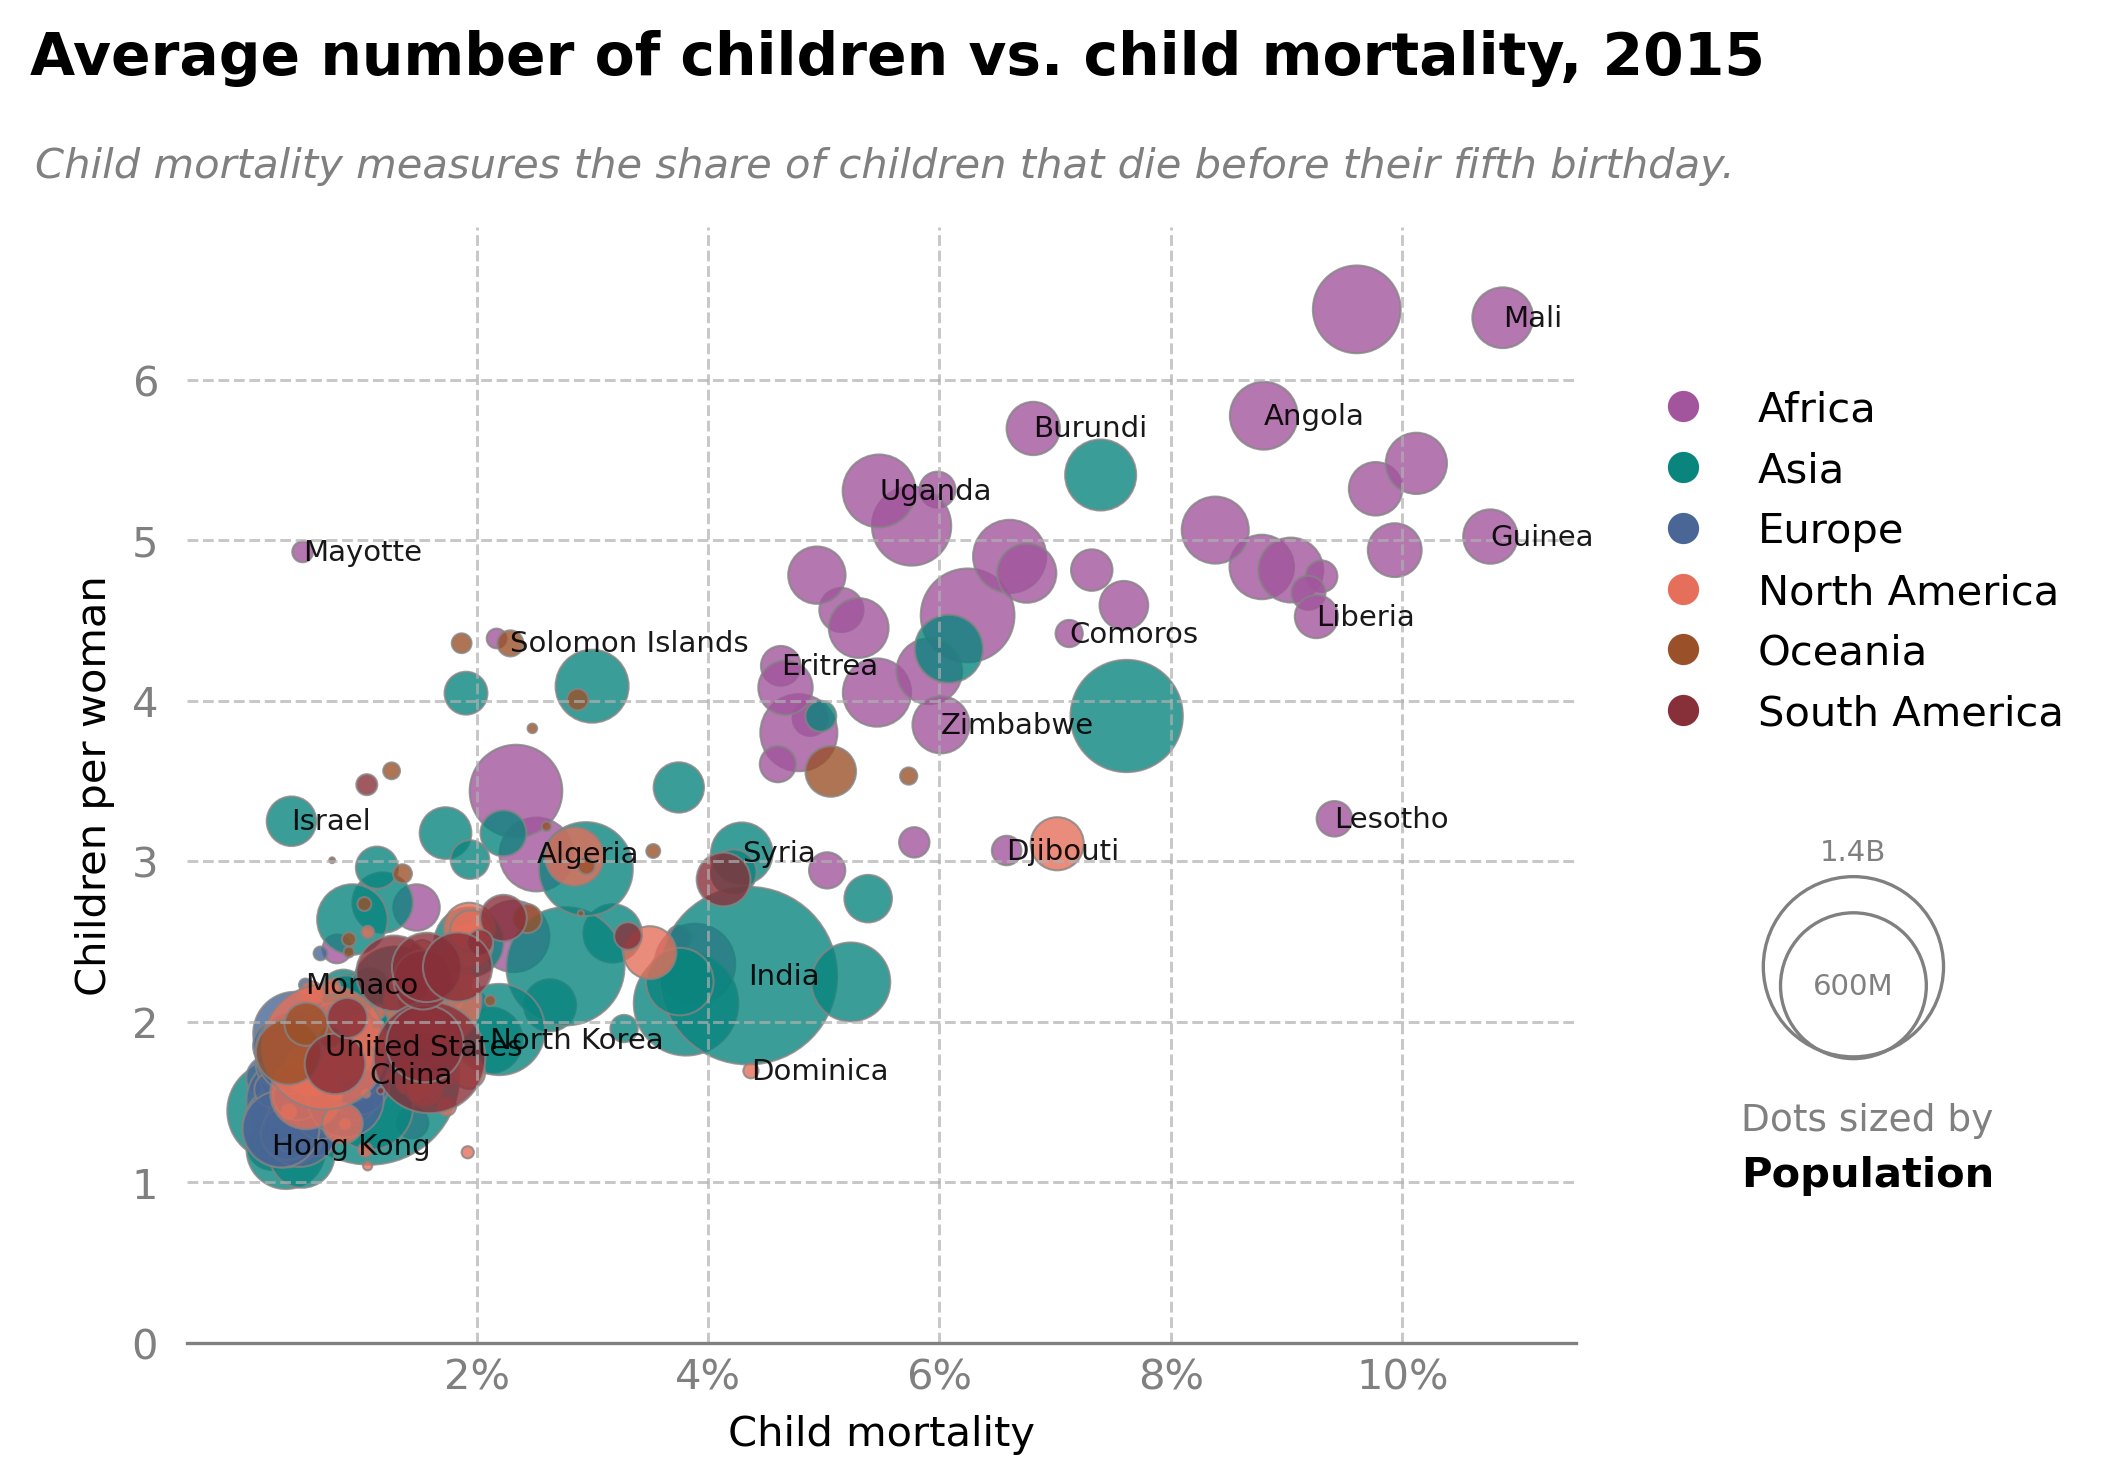

In [6]:
fig, ax = plt.subplots(figsize=(7,5), dpi=300)
# Title
fig.suptitle("Average number of children vs. child mortality, 2015",
             fontsize=14, fontweight="bold", x=0.0, ha="left", color="black")
ax.set_title("Child mortality measures the share of children that die before their fifth birthday.",
             fontsize=10, style="italic", color="gray", loc="left", x=-0.11, pad=12)


# Scatter plot
for cont, g in d2015.groupby("Continent"):
    ax.scatter(
        g[mort_col], g[fert_col],
        s=g["marker_size"], alpha=0.8,
        c=continent_colors.get(cont,"k"),
        edgecolors="#848484", linewidths=0.5,
        label=cont
    )



# Scattered Country name and China/US/India
for _, r in d2015.loc[label_mask].iterrows():
    ax.text(r[mort_col], r[fert_col], r["Entity"],
            fontsize=7, ha="left", va="center", alpha=0.9)


ax.set_ylim(0,6.95)
ax.set_ylabel("Children per woman")
ax.tick_params(axis="y", left=False, labelleft=True, colors="gray")

ax.set_xlim(-0.5,11.5)
ax.set_xlabel("Child mortality")
ax.set_xticks([2,4,6,8,10])
ax.set_xticklabels([f"{i}%" for i in [2,4,6,8,10]], color='grey')

ax.tick_params(axis="x", length=0)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color("gray")

# Grid
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)

# Legend
handles = [
    Line2D([0],[0], marker="o", linestyle="",
           markerfacecolor=continent_colors[c],
           markeredgecolor="white", markeredgewidth=0.5,
           markersize=8, label=c)
    for c in sorted(continents)
]
ax.legend(handles=handles, title=None, frameon=False, 
          bbox_to_anchor=(1.02,0.7), loc="center left")



# ===== Bubble legend =====

ref_pops = [600_000_000, 1_400_000_000]  # 600M, 1.4B
labels = ["600M", "1.4B"]

ref_sizes = [np.sqrt(p) / 20 for p in ref_pops]

from matplotlib.transforms import blended_transform_factory
transform = blended_transform_factory(ax.transAxes, ax.transAxes)

x0, y0 = 1.2, 0.32

for i, (s, lab) in enumerate(zip(ref_sizes, labels)):
    ax.scatter(x0, [y0 + i*0.017], s=s,
               facecolors="none", edgecolors="gray", linewidths=0.8,
               transform=transform, clip_on=False)
    ax.text(x0, y0 + i*0.12, lab,
            transform=transform, ha="center", va="center",
            fontsize=7, color="gray")

ax.text(x0+0.01, y0 - 0.12, "Dots sized by",
        transform=transform, ha="center", va="center",
        fontsize=9, color="gray")

ax.text(x0+0.01, y0 - 0.17, "Population",
        transform=transform, ha="center", va="center",
        fontsize=10, color="black", fontweight="bold")

# plot
plt.tight_layout()
plt.show()



# For 2020

### Data Processing

In [7]:
# Simplify column names
fert_col = "Fertility rate - Sex: all - Age: all - Variant: estimates"
mort_col = "Child mortality rate - Sex: all - Age: 0-4 - Variant: estimates"
pop_col  = "Population (historical estimates)"

# Select 2020 data and remove NaN
d2020 = df_2020.dropna(subset=[fert_col, mort_col, pop_col, "Continent"]).copy()

# Point size = sqrt(population) scaling
d2020["marker_size"] = np.sqrt(d2020[pop_col]) / 20  # divisor can be adjusted

# Continent color mapping
continents = d2020["Continent"].dropna().unique().tolist()
palette = ["#A2559D","#0A857E","#496696","#E56F5A","#9A5129","#883039"] 
continent_colors = {c: palette[i % len(palette)]
                    for i, c in enumerate(sorted(continents))}


In [8]:
# Choose a country that is far away to name it, otherwise the picture will be messy

x_min, x_max = 0.0, 11.0
y_min, y_max = 0.0, 6.9

x = d2020[mort_col].to_numpy(dtype=float)
y = d2020[fert_col].to_numpy(dtype=float)

mask_in = (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)
idx_in = d2020.index[mask_in].to_numpy()

# Normalize to [0,1]
x_n = (x[mask_in] - x_min) / (x_max - x_min)
y_n = (y[mask_in] - y_min) / (y_max - y_min)
pts = np.column_stack([x_n, y_n])

selected_idx = []

# Farthest point sampling (FPS)
if len(pts) > 0:
    center = np.array([0.5, 0.5])
    d0 = np.linalg.norm(pts - center, axis=1)
    start_idx_local = int(d0.argmax())

    selected_local = [start_idx_local]
    min_d = np.linalg.norm(pts - pts[start_idx_local], axis=1)

    target_k = min(20, len(pts))
    while len(selected_local) < target_k:
        nxt = int(min_d.argmax())
        selected_local.append(nxt)
        min_d = np.minimum(min_d, np.linalg.norm(pts - pts[nxt], axis=1))

    selected_idx = idx_in[np.array(selected_local, dtype=int)]

# ===== China / United States / India =====
must_have = d2020[d2020["Entity"].isin(["China","United States","India"])].index
selected_idx = np.unique(np.concatenate([selected_idx, must_have]))

label_mask = d2020.index.isin(selected_idx)


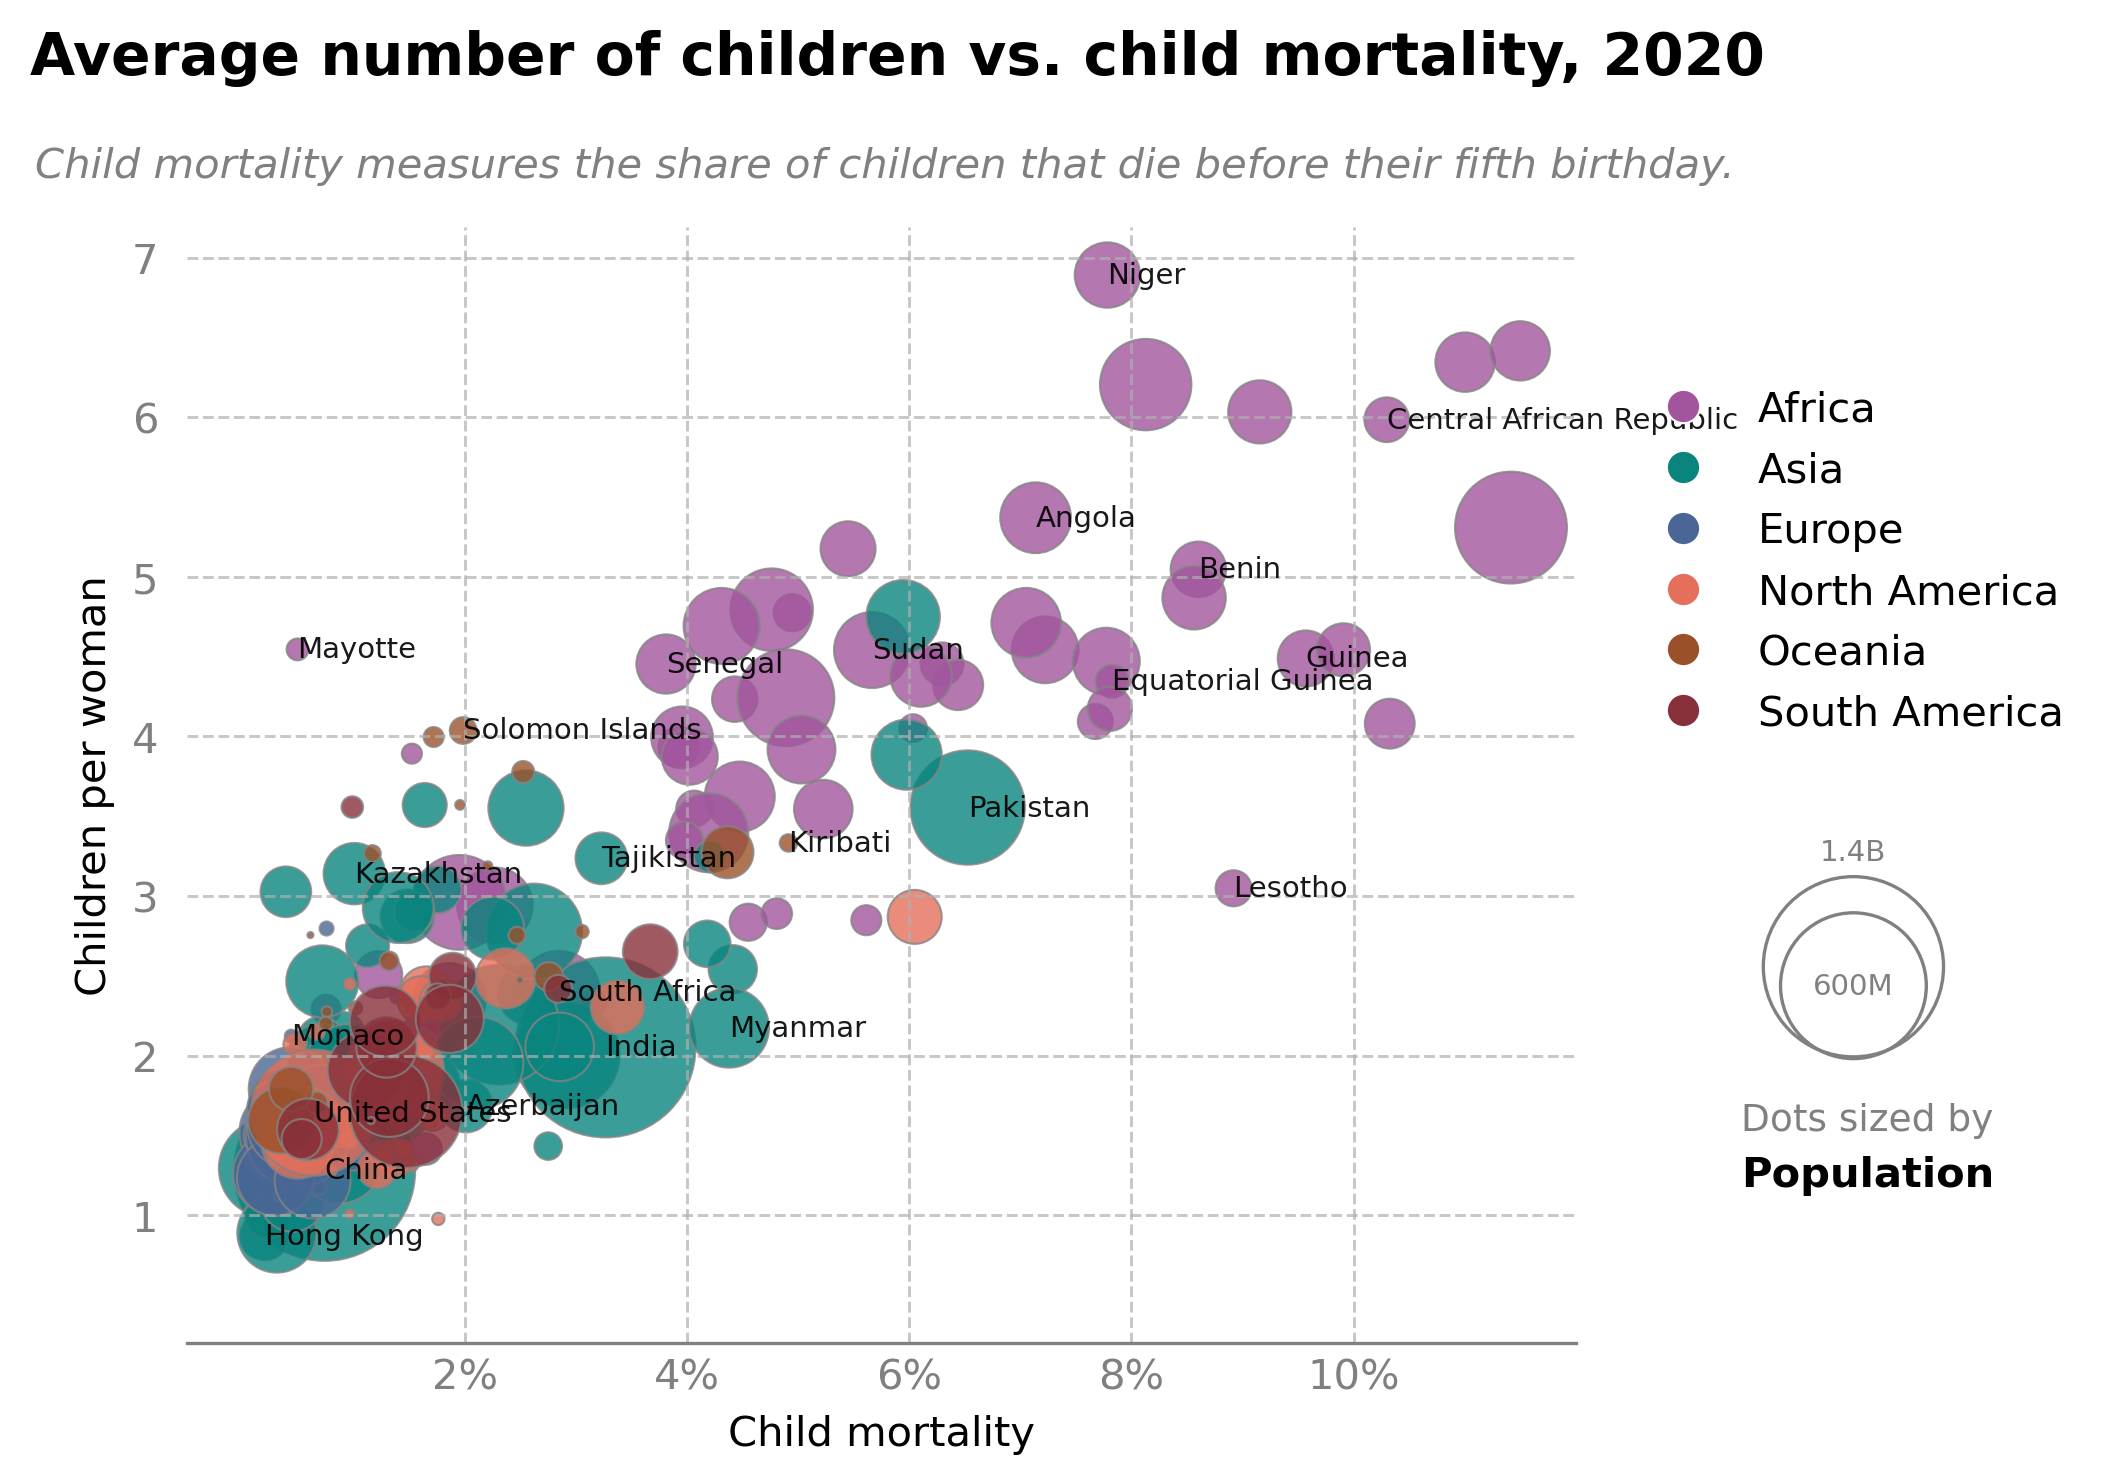

In [9]:
fig, ax = plt.subplots(figsize=(7,5), dpi=300)

# Title
fig.suptitle("Average number of children vs. child mortality, 2020",
             fontsize=14, fontweight="bold", x=0.0, ha="left", color="black")
ax.set_title("Child mortality measures the share of children that die before their fifth birthday.",
             fontsize=10, style="italic", color="gray", loc="left", x=-0.11, pad=12)

# Scatter plot
for cont, g in d2020.groupby("Continent"):
    ax.scatter(
        g[mort_col], g[fert_col],
        s=g["marker_size"], alpha=0.8,
        c=continent_colors.get(cont,"k"),
        edgecolors="#848484", linewidths=0.5,
        label=cont
    )

# Scattered Country name and China/US/India
for _, r in d2020.loc[label_mask].iterrows():
    ax.text(r[mort_col], r[fert_col], r["Entity"],
            fontsize=7, ha="left", va="center", alpha=0.9)

# Y axis
ax.set_ylim(0.2)
ax.set_ylabel("Children per woman")
ax.tick_params(axis="y", left=False, labelleft=True, colors="gray")

# X axis
ax.set_xlim(-0.5,12)
ax.set_xlabel("Child mortality")
ax.set_xticks([2,4,6,8,10])
ax.set_xticklabels([f"{i}%" for i in [2,4,6,8,10]], color='grey')

ax.tick_params(axis="x", length=0)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color("gray")

# Grid
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)

# Legend
handles = [
    Line2D([0],[0], marker="o", linestyle="",
           markerfacecolor=continent_colors[c],
           markeredgecolor="white", markeredgewidth=0.5,
           markersize=8, label=c)
    for c in sorted(continents)
]
ax.legend(handles=handles, title=None, frameon=False, 
          bbox_to_anchor=(1.02,0.7), loc="center left")

# ===== Bubble legend =====
ref_pops = [600_000_000, 1_400_000_000]  # 600M, 1.4B
labels = ["600M", "1.4B"]

ref_sizes = [np.sqrt(p) / 20 for p in ref_pops]

from matplotlib.transforms import blended_transform_factory
transform = blended_transform_factory(ax.transAxes, ax.transAxes)

x0, y0 = 1.2, 0.32

for i, (s, lab) in enumerate(zip(ref_sizes, labels)):
    ax.scatter(x0, [y0 + i*0.017], s=s,
               facecolors="none", edgecolors="gray", linewidths=0.8,
               transform=transform, clip_on=False)
    ax.text(x0, y0 + i*0.12, lab,
            transform=transform, ha="center", va="center",
            fontsize=7, color="gray")

ax.text(x0+0.01, y0 - 0.12, "Dots sized by",
        transform=transform, ha="center", va="center",
        fontsize=9, color="gray")

ax.text(x0+0.01, y0 - 0.17, "Population",
        transform=transform, ha="center", va="center",
        fontsize=10, color="black", fontweight="bold")

# plot
plt.tight_layout()
plt.show()


# For 2021

### Data Processing

In [10]:
# Simplify column names
fert_col = "Fertility rate - Sex: all - Age: all - Variant: estimates"
mort_col = "Child mortality rate - Sex: all - Age: 0-4 - Variant: estimates"
pop_col  = "Population (historical estimates)"

# Select 2021 data and remove NaN
d2021 = df_2021.dropna(subset=[fert_col, mort_col, pop_col, "Continent"]).copy()

# Point size = sqrt(population) scaling
d2021["marker_size"] = np.sqrt(d2021[pop_col]) / 20  # divisor can be adjusted

# Continent color mapping
continents = d2021["Continent"].dropna().unique().tolist()
palette = ["#A2559D","#0A857E","#496696","#E56F5A","#9A5129","#883039"] 
continent_colors = {c: palette[i % len(palette)]
                    for i, c in enumerate(sorted(continents))}


In [11]:
# Choose a country that is far away to name it, otherwise the picture will be messy

x_min, x_max = 0.0, 11.0
y_min, y_max = 0.0, 6.9

x = d2021[mort_col].to_numpy(dtype=float)
y = d2021[fert_col].to_numpy(dtype=float)

mask_in = (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)
idx_in = d2021.index[mask_in].to_numpy()

# Normalize to [0,1]
x_n = (x[mask_in] - x_min) / (x_max - x_min)
y_n = (y[mask_in] - y_min) / (y_max - y_min)
pts = np.column_stack([x_n, y_n])

selected_idx = []

# Farthest point sampling (FPS)
if len(pts) > 0:
    center = np.array([0.5, 0.5])
    d0 = np.linalg.norm(pts - center, axis=1)
    start_idx_local = int(d0.argmax())

    selected_local = [start_idx_local]
    min_d = np.linalg.norm(pts - pts[start_idx_local], axis=1)

    target_k = min(20, len(pts))
    while len(selected_local) < target_k:
        nxt = int(min_d.argmax())
        selected_local.append(nxt)
        min_d = np.minimum(min_d, np.linalg.norm(pts - pts[nxt], axis=1))

    selected_idx = idx_in[np.array(selected_local, dtype=int)]

# ===== China / United States / India =====
must_have = d2021[d2021["Entity"].isin(["China","United States","India"])].index
selected_idx = np.unique(np.concatenate([selected_idx, must_have]))

label_mask = d2021.index.isin(selected_idx)


### Plot 2021

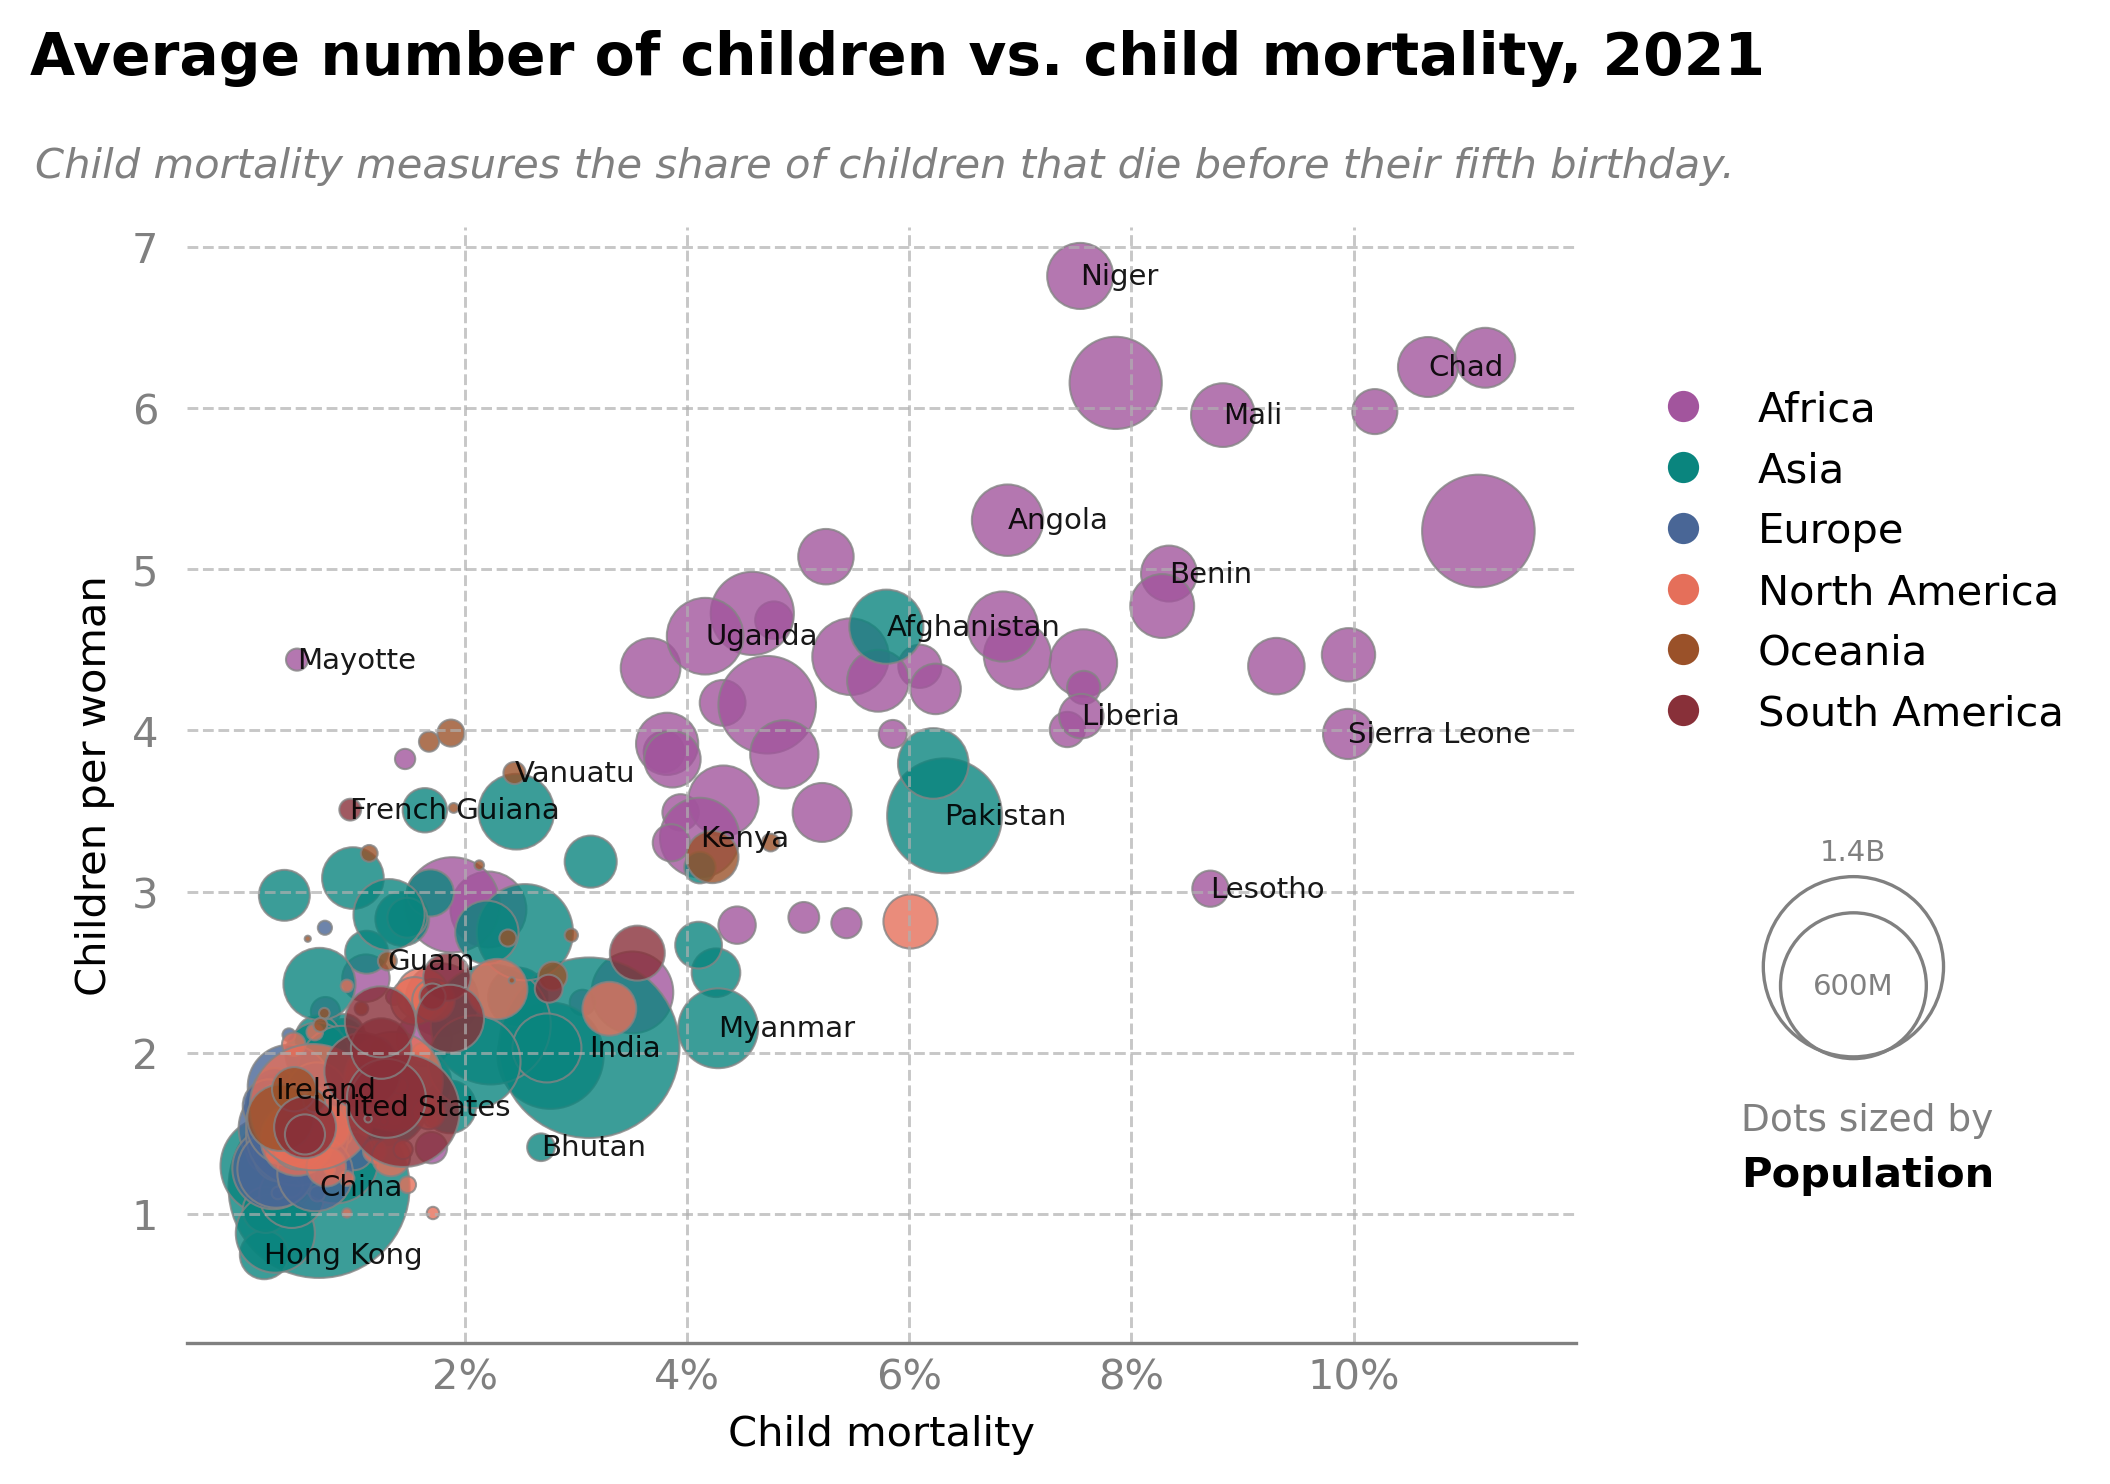

In [12]:
fig, ax = plt.subplots(figsize=(7,5), dpi=300)

# Title
fig.suptitle("Average number of children vs. child mortality, 2021",
             fontsize=14, fontweight="bold", x=0.0, ha="left", color="black")
ax.set_title("Child mortality measures the share of children that die before their fifth birthday.",
             fontsize=10, style="italic", color="gray", loc="left", x=-0.11, pad=12)

# Scatter plot
for cont, g in d2021.groupby("Continent"):
    ax.scatter(
        g[mort_col], g[fert_col],
        s=g["marker_size"], alpha=0.8,
        c=continent_colors.get(cont,"k"),
        edgecolors="#848484", linewidths=0.5,
        label=cont
    )

# Scattered Country name and China/US/India
for _, r in d2021.loc[label_mask].iterrows():
    ax.text(r[mort_col], r[fert_col], r["Entity"],
            fontsize=7, ha="left", va="center", alpha=0.9)

# Y axis
ax.set_ylim(0.2)
ax.set_ylabel("Children per woman")
ax.tick_params(axis="y", left=False, labelleft=True, colors="gray")

# X axis
ax.set_xlim(-0.5,12)
ax.set_xlabel("Child mortality")
ax.set_xticks([2,4,6,8,10])
ax.set_xticklabels([f"{i}%" for i in [2,4,6,8,10]], color='grey')

ax.tick_params(axis="x", length=0)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color("gray")

# Grid
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)

# Legend
handles = [
    Line2D([0],[0], marker="o", linestyle="",
           markerfacecolor=continent_colors[c],
           markeredgecolor="white", markeredgewidth=0.5,
           markersize=8, label=c)
    for c in sorted(continents)
]
ax.legend(handles=handles, title=None, frameon=False, 
          bbox_to_anchor=(1.02,0.7), loc="center left")

# ===== Bubble legend =====
ref_pops = [600_000_000, 1_400_000_000]  # 600M, 1.4B
labels = ["600M", "1.4B"]

ref_sizes = [np.sqrt(p) / 20 for p in ref_pops]

from matplotlib.transforms import blended_transform_factory
transform = blended_transform_factory(ax.transAxes, ax.transAxes)

x0, y0 = 1.2, 0.32

for i, (s, lab) in enumerate(zip(ref_sizes, labels)):
    ax.scatter(x0, [y0 + i*0.017], s=s,
               facecolors="none", edgecolors="gray", linewidths=0.8,
               transform=transform, clip_on=False)
    ax.text(x0, y0 + i*0.12, lab,
            transform=transform, ha="center", va="center",
            fontsize=7, color="gray")

ax.text(x0+0.01, y0 - 0.12, "Dots sized by",
        transform=transform, ha="center", va="center",
        fontsize=9, color="gray")

ax.text(x0+0.01, y0 - 0.17, "Population",
        transform=transform, ha="center", va="center",
        fontsize=10, color="black", fontweight="bold")

# plot
plt.tight_layout()
plt.show()


# Grad homework

In addition to this, <span style="color:red">**graduate students(those registered for 227 as opposed to 127)** should recreate one other plot of your choice from the website linked at the top of the page.</span> 
To do this, you will need to get data from [Our World in Data: Fertility Rate](https://ourworldindata.org/fertility-rate) for the plot you pick by clicking on the image and selecting download.  

In [13]:
df_g = pd.read_csv(r'children-per-woman-fertility-rate-vs-level-of-prosperity.csv') 

In [14]:
# variables
fert_col = "Fertility rate - Sex: all - Age: all - Variant: estimates"
gdp_col  = "GDP per capita (output, multiple price benchmarks)"
pop_col  = "Population (historical)"  


# -- Continent mapping using 2015 data (Code priority) --
continent_map = (
    d2015.dropna(subset=["Code", "Continent"])
         .drop_duplicates("Code")
         .set_index("Code")["Continent"]
)

# 1999 cleanning and processing data 
d1999 = df_g.dropna(subset=[fert_col, gdp_col, pop_col]).copy()

# add Continent
d1999["Continent"] = d1999["Code"].map(continent_map)

d1999["marker_size"] = np.sqrt(d1999[pop_col]) / 20

# color
continents = d1999["Continent"].dropna().unique().tolist()
palette = ["#A2559D","#0A857E","#496696","#E56F5A","#9A5129","#883039"]
continent_colors = {c: palette[i % len(palette)] for i, c in enumerate(sorted(continents))}



In [15]:
# Select 20 points within the specified range and as dispersed as possible on the plane to mark (+ mandatory China/US/India)

# axis range：x log10(GDP)
x_log = np.log10(d1999[gdp_col].astype(float))
y     = d1999[fert_col].astype(float)

x_min, x_max = np.nanpercentile(x_log, [1, 99])   
y_min, y_max = 0.0, 6.5                        

mask_in = (x_log >= x_min) & (x_log <= x_max) & (y >= y_min) & (y <= y_max)
idx_in = d1999.index[mask_in].to_numpy()

# Normalize to [0,1] (using fixed axis range)
x_n = (x_log[mask_in] - x_min) / (x_max - x_min + 1e-9)
y_n = (y[mask_in]      - y_min) / (y_max - y_min + 1e-9)
pts = np.column_stack([x_n, y_n])

selected_idx = []

# Farthest-Point Sampling (FPS)
if len(pts) > 0:
    center = np.array([0.5, 0.5])
    d0 = np.linalg.norm(pts - center, axis=1)
    start_idx_local = int(d0.argmax())

    selected_local = [start_idx_local]
    min_d = np.linalg.norm(pts - pts[start_idx_local], axis=1)

    target_k = min(20, len(pts))
    while len(selected_local) < target_k:
        nxt = int(min_d.argmax())
        selected_local.append(nxt)
        min_d = np.minimum(min_d, np.linalg.norm(pts - pts[nxt], axis=1))

    selected_idx = idx_in[np.array(selected_local, dtype=int)]

# China / United States / India
must_have = d1999[d1999["Entity"].isin(["China","United States","India"])].index
selected_idx = np.unique(np.concatenate([selected_idx, must_have]))

label_mask_1999 = d1999.index.isin(selected_idx)


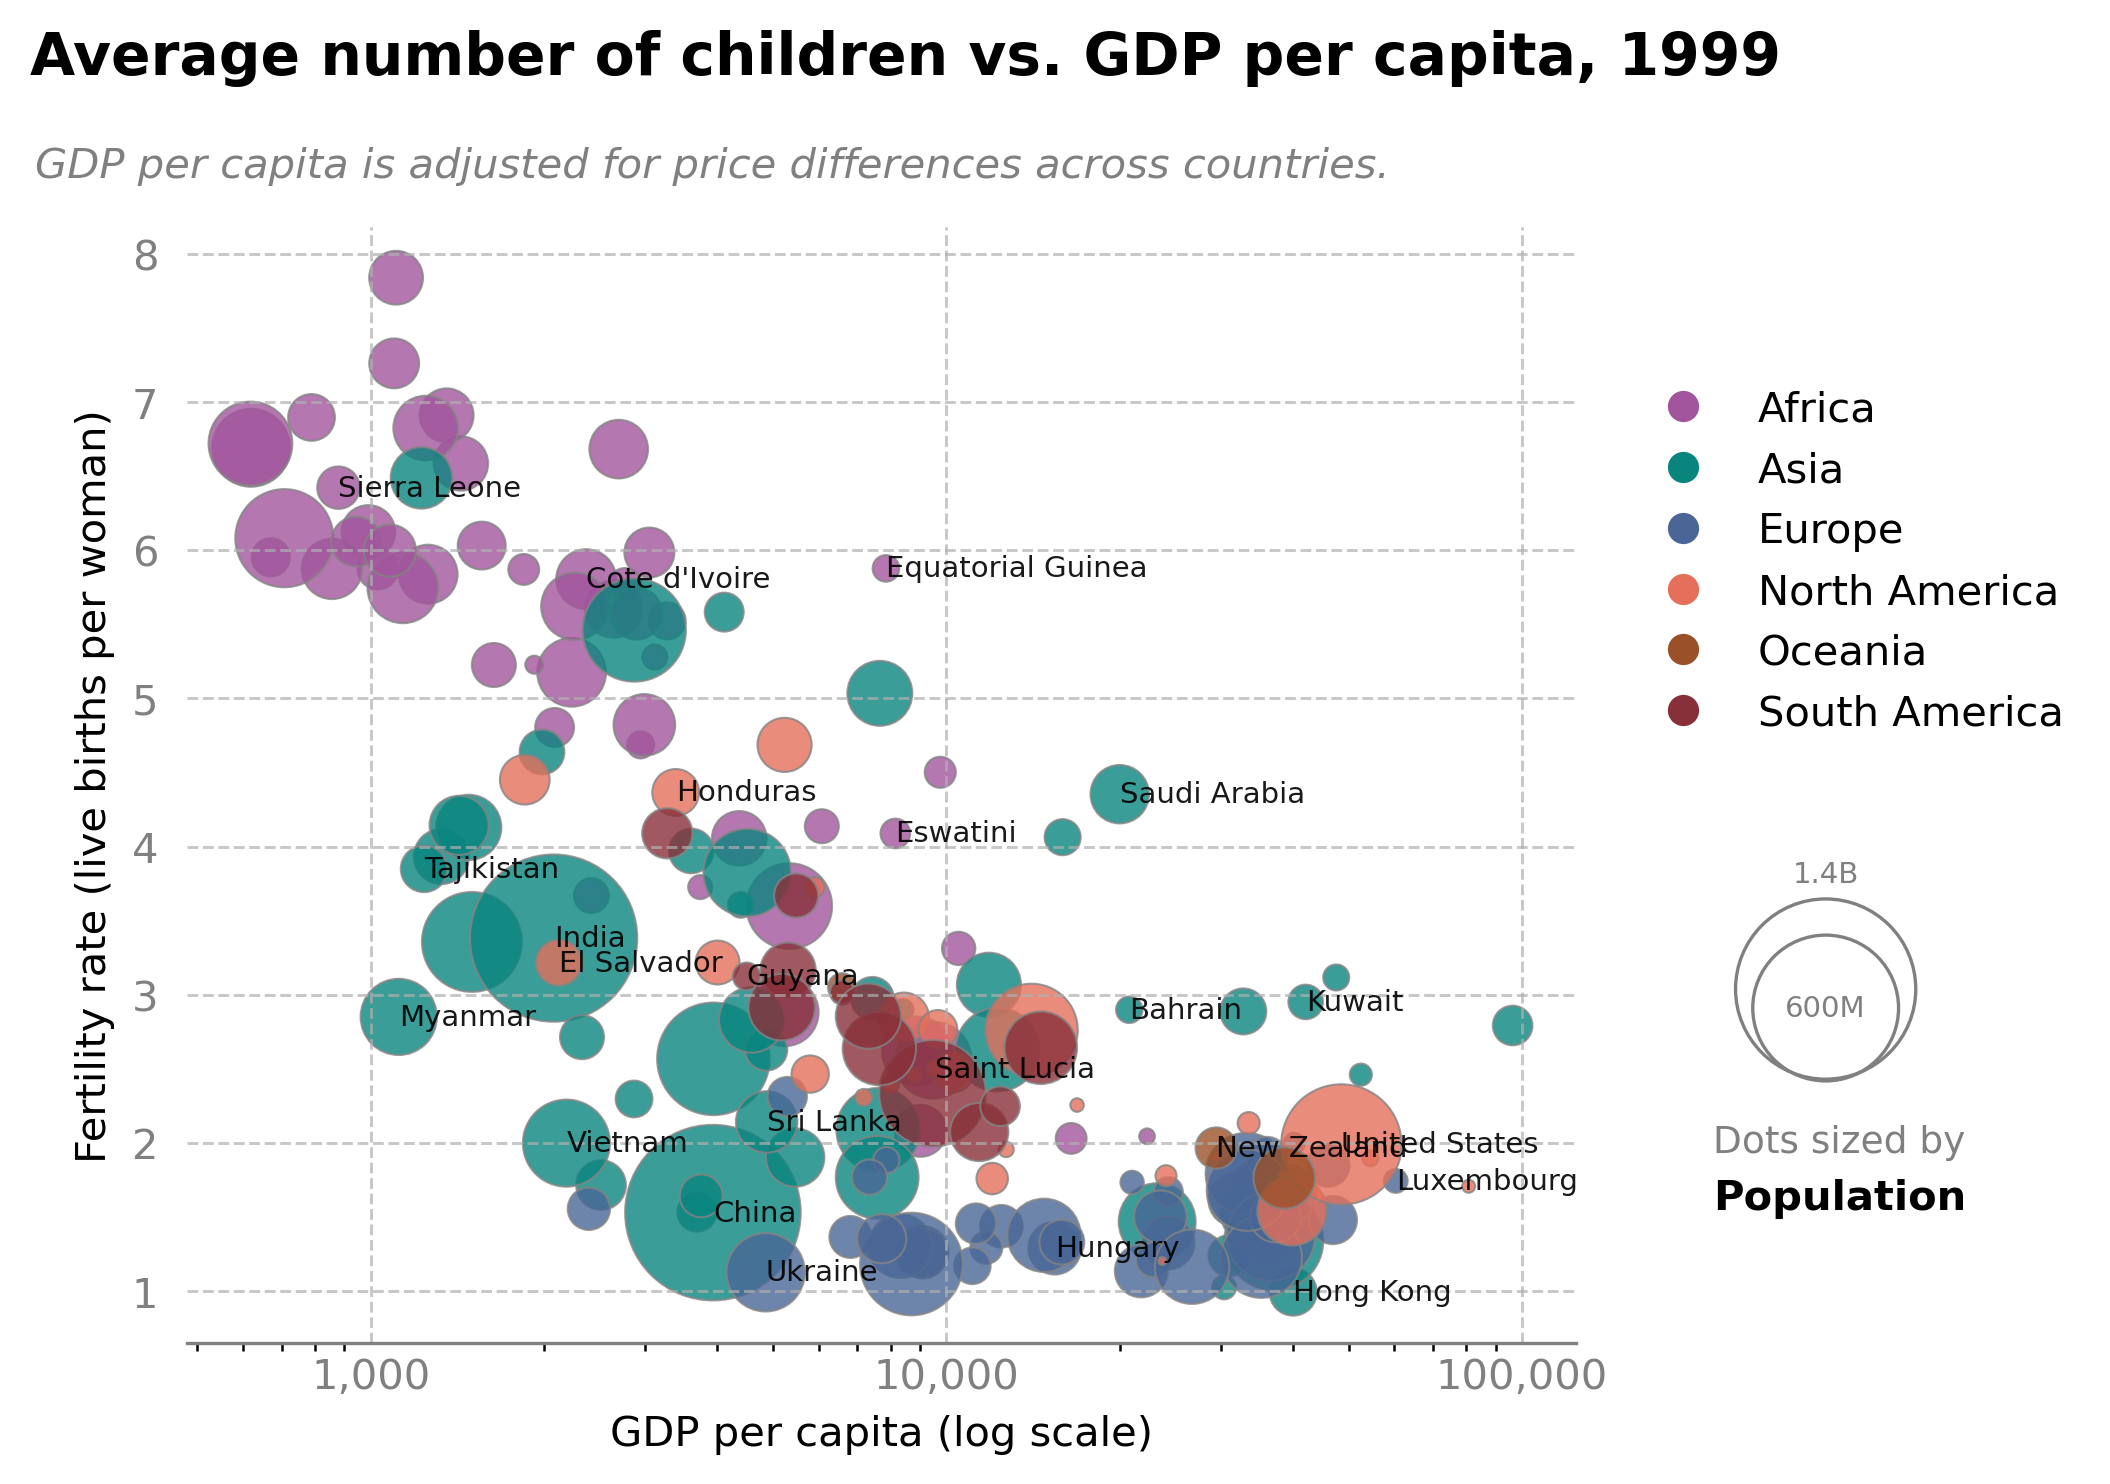

In [18]:
fig, ax = plt.subplots(figsize=(7,5), dpi=300)

# title
fig.suptitle("Average number of children vs. GDP per capita, 1999",
             fontsize=14, fontweight="bold", x=0.0, ha="left", color="black")
ax.set_title("GDP per capita is adjusted for price differences across countries.",
             fontsize=10, style="italic", color="gray", loc="left", x=-0.11, pad=12)

# scatter
for cont, g in d1999.groupby("Continent"):
    ax.scatter(
        g[gdp_col], g[fert_col],
        s=g["marker_size"], alpha=0.8,
        c=continent_colors.get(cont, "k"),
        edgecolors="#848484", linewidths=0.5,
        label=cont
    )

# 20 ponits and + China/US/India
for _, r in d1999.loc[label_mask_1999].iterrows():
    ax.text(r[gdp_col], r[fert_col], r["Entity"],
            fontsize=7, ha="left", va="center", alpha=0.9)


ax.set_xscale("log")
ax.set_xlabel("GDP per capita (log scale)")
ax.set_ylabel("Fertility rate (live births per woman)")


ax.tick_params(axis="x", length=0, colors="gray")
ax.tick_params(axis="y", left=False, colors="gray")
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color("gray")
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)


ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{int(v):,}" if v >= 1000 else f"{v:g}"))

# legend
handles = [
    Line2D([0],[0], marker="o", linestyle="",
           markerfacecolor=continent_colors[c],
           markeredgecolor="white", markeredgewidth=0.5,
           markersize=8, label=c)
    for c in sorted(continents)
]
ax.legend(handles=handles, title=None, frameon=False,
          bbox_to_anchor=(1.02,0.7), loc="center left")

# ===== bubble legend =====
ref_pops = [600_000_000, 1_400_000_000]  # 600M, 1.4B
labels = ["600M", "1.4B"]
ref_sizes = [np.sqrt(p) / 20 for p in ref_pops]

from matplotlib.transforms import blended_transform_factory
transform = blended_transform_factory(ax.transAxes, ax.transAxes)

x0, y0 = 1.18, 0.30  
for i, (s, lab) in enumerate(zip(ref_sizes, labels)):
    ax.scatter(x0, [y0 + i*0.017], s=s,
               facecolors="none", edgecolors="gray", linewidths=0.8,
               transform=transform, clip_on=False)
    ax.text(x0, y0 + i*0.12, lab,
            transform=transform, ha="center", va="center",
            fontsize=7, color="gray")

ax.text(x0+0.01, y0 - 0.12, "Dots sized by",
        transform=transform, ha="center", va="center",
        fontsize=9, color="gray")
ax.text(x0+0.01, y0 - 0.17, "Population",
        transform=transform, ha="center", va="center",
        fontsize=10, color="black", fontweight="bold")

plt.tight_layout()
plt.show()


### **Exra Credit**

Create an animation recreating one that was shown in the TED talk.  Comment your code and make sure to provide references or webpage links for the resources you utilize to generate this.  Turn both the animation and the code in this Jupyter notebook in for full extra credit points. 

In [19]:
import numpy as np
import pandas as pd

# column name
fert_col = "Fertility rate - Sex: all - Age: all - Variant: estimates"
mort_col = "Child mortality rate - Sex: all - Age: 0-4 - Variant: estimates"
pop_col  = "Population (historical estimates)" 
year_col = "Year"
code_col = "Code"
name_col = "Entity"
cont_col = "Continent"

# Create a Continent map using 2015
df_2015 = df[df[year_col] == 2015].copy()
continent_map = (df_2015.dropna(subset=[code_col, cont_col])
                          .drop_duplicates(code_col)
                          .set_index(code_col)[cont_col])

# Select the required columns and fill in Continent
keep_cols = [name_col, code_col, year_col, fert_col, mort_col, pop_col, cont_col]
d = df[keep_cols].copy()
d[cont_col] = d[cont_col].fillna(d[code_col].map(continent_map))

d = d.dropna(subset=[fert_col, mort_col, pop_col, cont_col])

# Point size (√population/20)
d["marker_size"] = np.sqrt(d[pop_col].astype(float).clip(lower=1)) / 20

# 5) time series
years = sorted(d[year_col].dropna().astype(int).unique())

# 6) color
continents = sorted(d[cont_col].dropna().unique().tolist())
palette = ["#A2559D","#0A857E","#496696","#E56F5A","#9A5129","#883039"]
continent_colors = {c: palette[i % len(palette)] for i, c in enumerate(continents)}

year_groups = {y: (d[d[year_col] == y]
                   .sort_values(name_col)
                   .drop_duplicates(subset=[name_col], keep="last"))
               for y in years}



In [ ]:
x_min, x_max = 0.0, 11.0
y_min, y_max = 0.0, 6.99

fig, ax = plt.subplots(figsize=(7,5), dpi=200)

def draw_frame(y):
    ax.clear()

    ax.set_xlim(x_min, x_max + 0.5)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Child mortality")
    ax.set_ylabel("Children per woman")
    ax.set_xticks([2,4,6,8,10])
    ax.set_xticklabels([f"{i}%" for i in [2,4,6,8,10]], color="gray")
    ax.tick_params(axis="x", length=0, colors="gray")
    ax.tick_params(axis="y", left=False, colors="gray")
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_color("gray")
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)

    # title
    fig.suptitle("Average number of children vs. child mortality",
                 fontsize=16, fontweight="bold", x=0.0, ha="left", color="black")
    ax.set_title("Child mortality measures the share of children that die before their fifth birthday.",
                 fontsize=10, style="italic", color="gray", loc="left", x=-0.11, pad=12)
    ax.text(0.98, 0.92, str(y), transform=ax.transAxes,
            ha="right", va="center", fontsize=26, alpha=0.2, fontweight="bold")

    # scatter
    g = year_groups[y]
    for cont, sub in g.groupby(cont_col):
        ax.scatter(sub[mort_col], sub[fert_col],
                   s=sub["marker_size"], alpha=0.8,
                   c=continent_colors.get(cont, "k"),
                   edgecolors="#848484", linewidths=0.5)

    # legend continent
    handles = [Line2D([0],[0], marker="o", linestyle="",
                      markerfacecolor=continent_colors[c],
                      markeredgecolor="#848484", markeredgewidth=0.5,
                      markersize=8, label=c)
               for c in continents]
    ax.legend(handles=handles, frameon=False, loc=2)

    # legend population
    ref_pops  = [600_000_000, 1_400_000_000]  # 600M / 1.4B
    ref_sizes = [np.sqrt(p) / 20 for p in ref_pops]
    labels    = ["600M", "1.4B"]

    transform = blended_transform_factory(ax.transAxes, ax.transAxes)
    x0, y0 = 0.4, 0.85  
    for i, (s, lab) in enumerate(zip(ref_sizes, labels)):
        ax.scatter(x0, [y0 + i*0.017], s=s, facecolors="none",
                   edgecolors="gray", linewidths=0.8,
                   transform=transform, clip_on=False)
        ax.text(x0, y0 + i*0.12, lab, transform=transform,
                ha="center", va="center", fontsize=7, color="gray")
    ax.text(x0+0.01, y0 - 0.12, "Dots sized by",
            transform=transform, ha="center", va="center",
            fontsize=9, color="gray")
    ax.text(x0+0.01, y0 - 0.17, "Population",
            transform=transform, ha="center", va="center",
            fontsize=10, color="black", fontweight="bold")

def init():
    draw_frame(years[0])
    return []

def update(i):
    draw_frame(years[i])
    return []

anim = FuncAnimation(fig, update, init_func=init,
                     frames=len(years), interval=800, blit=False)

from IPython.display import HTML, display
plt.close(fig)              
display(HTML(anim.to_jshtml()))
